## Analisis exploratorio
Autor: Mauricio Olguín Sánchez
Matricula: A01711522

### Sobre el _dataset_ escogido

El _dataset_ escogido pertenece al _Bureau of Transportation Statistics_ (BTS) de EE. UU. (_Airline Service Quality Performance_). Dentro de su misma descripción, dice que su propósito es para predecir el tiempo de retraso en la salida de los vuelos. Contiene un millon (1M) de instancias y diez _features_, donde siete son variables numéricas y tres 

### Primera acercamiento
Para esta primera exploración, imprimiré os datos básicos del dataset.

In [ ]:
# Datos obtenidos de https://www.openml.org/search?type=data&sort=qualities.NumberOfInstances&status=active&qualities.NumberOfClasses=lte_1&order=desc&qualities.NumberOfInstances=between_100000_1000000&id=42721

import pandas as pd
# Cargo scipy sólo
from scipy.io import arff
# code
pd.set_option('display.max_rows', 100)
arff_file = arff.loadarff('./airlines_train_regression_1000000.arff')
df = pd.DataFrame(arff_file[0])
df

,DepDelay,Month,DayofMonth,DayOfWeek,CRSDepTime,CRSArrTime,UniqueCarrier,Origin,Dest,Distance
0,8.0,10.0,11.0,7.0,1300.0,1535.0,b'AA',b'LAX',b'HNL',2556.0
1,-3.0,10.0,10.0,6.0,2035.0,2110.0,b'AA',b'OGG',b'HNL',100.0
2,6.0,10.0,26.0,1.0,1200.0,1446.0,b'AA',b'JFK',b'LAX',2475.0
3,1.0,10.0,9.0,5.0,1145.0,1512.0,b'AA',b'JFK',b'SFO',2586.0
4,0.0,10.0,16.0,5.0,930.0,1149.0,b'AA',b'SFO',b'HNL',2399.0
...,...,...,...,...,...,...,...,...,...,...
999995,-1.0,7.0,30.0,2.0,835.0,940.0,b'WN',b'STL',b'MKE',317.0
999996,1.0,7.0,29.0,1.0,1225.0,1633.0,b'YV',b'PHX',b'SAT',843.0
999997,-2.0,7.0,30.0,2.0,1515.0,1735.0,b'YV',b'BHM',b'CLT',350.0
999998,8.0,7.0,25.0,4.0,1335.0,1646.0,b'YV',b'ORD',b'PWM',900.0


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   DepDelay       1000000 non-null  float64
 1   Month          1000000 non-null  float64
 2   DayofMonth     1000000 non-null  float64
 3   DayOfWeek      1000000 non-null  float64
 4   CRSDepTime     1000000 non-null  float64
 5   CRSArrTime     1000000 non-null  float64
 6   UniqueCarrier  1000000 non-null  object 
 7   Origin         1000000 non-null  object 
 8   Dest           1000000 non-null  object 
 9   Distance       1000000 non-null  float64
dtypes: float64(7), object(3)
memory usage: 76.3+ MB


Las columnas UniqueCarrier, Origin y Dest sus tipos de datos no son los correctos, ya que las cadenas de caracteres los ha leído como "object" y no como "str", por lo cual, cambiaré estos datos a strings puros.

In [46]:
df["UniqueCarrier"] = df["UniqueCarrier"].str.decode('utf-8')
df["Origin"] = df["Origin"].str.decode('utf-8')
df["Dest"] = df["Dest"].str.decode('utf-8')
df

,DepDelay,Month,DayofMonth,DayOfWeek,CRSDepTime,CRSArrTime,UniqueCarrier,Origin,Dest,Distance
0,8.0,10.0,11.0,7.0,1300.0,1535.0,AA,LAX,HNL,2556.0
1,-3.0,10.0,10.0,6.0,2035.0,2110.0,AA,OGG,HNL,100.0
2,6.0,10.0,26.0,1.0,1200.0,1446.0,AA,JFK,LAX,2475.0
3,1.0,10.0,9.0,5.0,1145.0,1512.0,AA,JFK,SFO,2586.0
4,0.0,10.0,16.0,5.0,930.0,1149.0,AA,SFO,HNL,2399.0
...,...,...,...,...,...,...,...,...,...,...
999995,-1.0,7.0,30.0,2.0,835.0,940.0,WN,STL,MKE,317.0
999996,1.0,7.0,29.0,1.0,1225.0,1633.0,YV,PHX,SAT,843.0
999997,-2.0,7.0,30.0,2.0,1515.0,1735.0,YV,BHM,CLT,350.0
999998,8.0,7.0,25.0,4.0,1335.0,1646.0,YV,ORD,PWM,900.0


Aquí vemos que lso datos cargan correctamente, con sus cabeceras bien colocadas.

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   DepDelay       1000000 non-null  float64
 1   Month          1000000 non-null  float64
 2   DayofMonth     1000000 non-null  float64
 3   DayOfWeek      1000000 non-null  float64
 4   CRSDepTime     1000000 non-null  float64
 5   CRSArrTime     1000000 non-null  float64
 6   UniqueCarrier  1000000 non-null  str    
 7   Origin         1000000 non-null  str    
 8   Dest           1000000 non-null  str    
 9   Distance       1000000 non-null  float64
dtypes: float64(7), str(3)
memory usage: 76.3 MB


In [48]:
df.describe()

,DepDelay,Month,DayofMonth,DayOfWeek,CRSDepTime,CRSArrTime,Distance
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,8.191935,6.496693,15.720187,3.944029,1333.301106,1492.460607,712.275619
std,28.877186,3.425559,8.787525,1.989687,473.972347,491.043639,556.836029
min,-1197.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,-3.000000,4.000000,8.000000,2.000000,930.000000,1115.000000,313.000000
50%,0.000000,6.000000,16.000000,4.000000,1325.000000,1520.000000,551.000000
75%,7.000000,9.000000,23.000000,6.000000,1725.000000,1911.000000,946.000000
max,2119.000000,12.000000,31.000000,7.000000,2400.000000,2400.000000,4983.000000


In [49]:
df.isna().sum()

DepDelay         0
Month            0
DayofMonth       0
DayOfWeek        0
CRSDepTime       0
CRSArrTime       0
UniqueCarrier    0
Origin           0
Dest             0
Distance         0
dtype: int64

De esta primera exploración, podemos destacar lo siguiente:
- No existen valores nulos para niguna instancia en ninguna columna.
- La variable a predecir será si un alumno, dadas sus condiciones, podría darse de baja de la escuela o no.

array([[<Axes: title={'center': 'DepDelay'}>,
        <Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'DayofMonth'}>],
       [<Axes: title={'center': 'DayOfWeek'}>,
        <Axes: title={'center': 'CRSDepTime'}>,
        <Axes: title={'center': 'CRSArrTime'}>],
       [<Axes: title={'center': 'Distance'}>, <Axes: >, <Axes: >]],
      dtype=object)

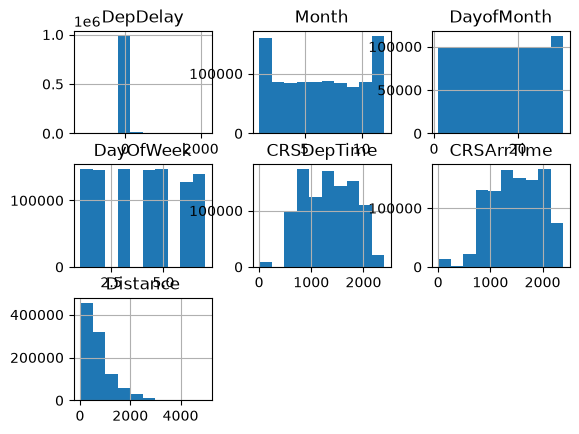

In [50]:
df.hist()